[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

39AF81A22A corresponding to Appendix in sig_sys_ex_11.tex

## Properties of the Fourier Matrix

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, ifft
from numpy.linalg import inv
from numpy.linalg import eig, eigh, norm

## Prepare Fourier Matrix

In [2]:
N = 2**2
k = np.arange(N)
K = np.outer(k, k)
F = np.exp(+1j*2*np.pi/N * K)
Fn = F / np.sqrt(N)

## Unitary Fourier Matrix Fn

**orthonormal**

In [3]:
if N < 5:
    print(Fn)

[[ 5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j
   5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j]
 [ 5.00000000e-01+0.0000000e+00j  3.06161700e-17+5.0000000e-01j
  -5.00000000e-01+6.1232340e-17j -9.18485099e-17-5.0000000e-01j]
 [ 5.00000000e-01+0.0000000e+00j -5.00000000e-01+6.1232340e-17j
   5.00000000e-01-1.2246468e-16j -5.00000000e-01+1.8369702e-16j]
 [ 5.00000000e-01+0.0000000e+00j -9.18485099e-17-5.0000000e-01j
  -5.00000000e-01+1.8369702e-16j  2.75545530e-16+5.0000000e-01j]]


In [4]:
print(np.allclose(Fn.T, Fn))  # check symmetry

True


In [5]:
# properties
print(np.allclose(Fn.conj(), Fn.conj().T))
print(np.allclose(Fn.conj().T, inv(Fn)))
print(np.allclose(Fn.conj(), inv(Fn)))

True
True
True


In [6]:
# full rank -> check left and right inverse via .conj().T
print(np.allclose(Fn.conj().T @ Fn, np.eye(N)))
print(np.allclose(Fn @ Fn.conj().T, np.eye(N)))

True
True


In [7]:
# full rank -> check left and right inverse via .conj()
print(np.allclose(Fn.conj() @ Fn, np.eye(N)))
print(np.allclose(Fn @ Fn.conj(), np.eye(N)))

True
True


In [8]:
# full rank -> check left and right inverse via inv()
print(np.allclose(inv(Fn) @ Fn, np.eye(N)))
print(np.allclose(Fn @ inv(Fn), np.eye(N)))

True
True


## Fourier Matrix

**orthogonal**

this is the 1/N-convention as used by `fft()` / `ifft()` in Matlab, Python with scipy and/or numpy

In [9]:
if N < 5:
    print(F)

[[ 1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j
   1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j  6.1232340e-17+1.0000000e+00j
  -1.0000000e+00+1.2246468e-16j -1.8369702e-16-1.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j -1.0000000e+00+1.2246468e-16j
   1.0000000e+00-2.4492936e-16j -1.0000000e+00+3.6739404e-16j]
 [ 1.0000000e+00+0.0000000e+00j -1.8369702e-16-1.0000000e+00j
  -1.0000000e+00+3.6739404e-16j  5.5109106e-16+1.0000000e+00j]]


In [10]:
print(np.allclose(F.T, F))  # check symmetry

True


In [11]:
# properties
print(np.allclose(F.conj(), F.conj().T))
print(np.allclose(F.conj().T / N, inv(F)))
print(np.allclose(F.conj() / N, inv(F)))

True
True
True


In [12]:
# full rank -> check left and right inverse via .conj().T / N
print(np.allclose(F.conj().T/N @ F, np.eye(N)))
print(np.allclose(F @ F.conj().T/N, np.eye(N)))

True
True


In [13]:
# full rank -> check left and right inverse via .conj() / N
print(np.allclose(F.conj()/N @ F, np.eye(N)))
print(np.allclose(F @ F.conj()/N, np.eye(N)))

True
True


In [14]:
# full rank -> check left and right inverse via inv()
print(np.allclose(inv(F) @ F, np.eye(N)))
print(np.allclose(F @ inv(F), np.eye(N)))

True
True


## Diagonalization of Permutation Matrix with Fourier Matrix

In [15]:
P = np.eye(N)
P = np.roll(P, -1, axis=0)  # in SigSys we start with k=0, so we roll P
P

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]])

In [16]:
# eigvals of P sorted with increasing angle
lmb = np.exp(+1j*2*np.pi/N*np.arange(N))
lmb

array([ 1.0000000e+00+0.0000000e+00j,  6.1232340e-17+1.0000000e+00j,
       -1.0000000e+00+1.2246468e-16j, -1.8369702e-16-1.0000000e+00j])

In [17]:
# the Fourier matrix includes the corresponding eigvecs
# sorting is already matched as we built F intentionally
Pr = F @ np.diag(lmb) @ inv(F)
np.allclose(Pr, P)

True

In [18]:
# so we find the eigvals of P numerically using F
L = np.diag(inv(F) @ P @ F)
# L matches the theoretical eigvals sorted with increasing angle
np.allclose(L, lmb)

True

Since $\mathbf{F}$ has nice properties (see above), we don't need to compute its inverse but rather we can use $\mathbf{F}^\mathrm{H}$ and even $\mathbf{F}^*$ 

In [19]:
# use 1/N * F.conj().T instead of inv(F)
Lh = np.diag(1/N*F.conj().T @ P @ F)
np.allclose(Lh, lmb)

True

In [20]:
# use 1/N * F.conj() instead of inv(F)
Lt = np.diag(1/N*F.conj() @ P @ F)
np.allclose(Lt, lmb)

True

Calculate eigenvecs/-vals completely numerically by `eig()` and check if we get same results as above

In [21]:
w, v = eig(P)

[ 3.14159265  1.57079633 -1.57079633  0.        ]


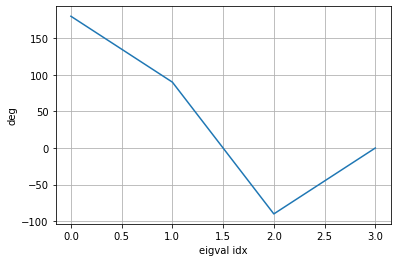

In [22]:
# the eigvals might not be sorted with increasing angles
tmp = np.angle(w)
print(tmp)
plt.plot(tmp * 180/np.pi)
plt.xlabel('eigval idx')
plt.ylabel('deg')
plt.grid(True)

In [23]:
tmp[tmp<0] = 2*np.pi + tmp[tmp<0]

[0.         1.57079633 3.14159265 4.71238898]


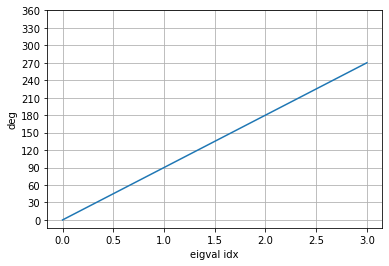

In [24]:
sort_index = np.argsort(tmp)
print(tmp[sort_index])
plt.plot(tmp[sort_index] * 180/np.pi)
plt.xlabel('eigval idx')
plt.ylabel('deg')
plt.yticks(np.arange(0,360+30,30))
plt.grid(True)

In [25]:
np.allclose(w[sort_index], lmb)

True

In [26]:
# eigvals are more tricky to align to F due to 'polarity' dof
# we do this hard coded for N=4 and hopefully the eig()
# will produce same results on other computers:
if N == 4:
    # v are unit vetors, so we scale with sqrt(N) to get unit amplitudes as in F
    tmp = v[:, sort_index]*np.sqrt(N)
    # hard coded 'polarity' change
    tmp[:, 0] *= -1
    tmp[:, 1] *= 1j
    tmp[:, 2] *= -1
    tmp[:, 3] *= -1j
    print(np.allclose(tmp, F))
    # we still having a orthonormal basis
    print(np.allclose(tmp @ inv(tmp), np.eye(N)))
    print(np.allclose(inv(tmp) @ tmp, np.eye(N)))

True
True
True


## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.